#Assignment -1

**Name:** Md. Jahid Gazi  
**ID:** 1000128068  
Medical image classification, Normal vs Pneumonia chest X-rays


**Dataset:** Chest X-Ray Pneumonia publicly available through Kaggle.






The CNN architecture follows:

**Input → Convolution → ReLU → Pooling → Convolution → ReLU → Pooling → Convolution → ReLU → Pooling → Flatten → Fully Connected → Output**



In [1]:
# 1. Setup & reproducibility
import os
import random
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)


Using device: cpu


## 2. Dataset Loading

We use the public **Chest X-Ray Pneumonia** dataset for binary classification:
- **Normal**
- **Pneumonia**


In [2]:
# 2. Download / locate the complete Kaggle dataset
# Dataset: Chest X-Ray Images (Pneumonia) — full dataset
# The dataset contains 5,863 JPEG X-ray images in two classes.

import os
from pathlib import Path

DATA_ROOT = None

try:
    import kagglehub
    DATA_ROOT = Path(kagglehub.dataset_download('paultimothymooney/chest-xray-pneumonia'))
    print('Kaggle dataset downloaded to:', DATA_ROOT)
except Exception as e:
    print('Automatic Kaggle download was not completed:', e)
    print('If needed, download the dataset from Kaggle and set DATA_ROOT manually.')
    # Example:
    # DATA_ROOT = Path('/content/chest-xray-pneumonia')


Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Kaggle dataset downloaded to: /kaggle/input/chest-xray-pneumonia


In [3]:
candidate_roots = [
    Path(DATA_ROOT) / 'chest_xray',
    Path(DATA_ROOT),
]

CHEST_ROOT = None
for p in candidate_roots:
    if (p / 'train').exists() and (p / 'test').exists():
        CHEST_ROOT = p
        break

if CHEST_ROOT is None:
    raise FileNotFoundError(
        'Could not find train/test folders. Set CHEST_ROOT manually to the extracted chest_xray folder.'
    )

TRAIN_DIR = CHEST_ROOT / 'train'
TEST_DIR = CHEST_ROOT / 'test'

print('Train:', TRAIN_DIR)
print('Test :', TEST_DIR)


Train: /kaggle/input/chest-xray-pneumonia/chest_xray/train
Test : /kaggle/input/chest-xray-pneumonia/chest_xray/test


## 3. Data Preprocessing and Train/Validation/Test Split


Chest X-rays are converted to RGB so the input matches the **3-channel CNN architecture**


In [4]:
IMG_SIZE = 32
BATCH_SIZE = 64
VAL_RATIO = 0.20

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(5),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))
])

full_train_base = datasets.ImageFolder(TRAIN_DIR, transform=None)
class_names = full_train_base.classes
print('Classes:', class_names)

n_total = len(full_train_base)
n_val = int(n_total * VAL_RATIO)
n_train = n_total - n_val

generator = torch.Generator().manual_seed(SEED)
train_subset, val_subset = random_split(full_train_base, [n_train, n_val], generator=generator)

class TransformSubset(torch.utils.data.Dataset):
    def __init__(self, subset, transform):
        self.subset = subset
        self.transform = transform

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        image, label = self.subset.dataset[self.subset.indices[idx]]
        image = image.convert('RGB')
        return self.transform(image), label

train_dataset = TransformSubset(train_subset, train_transform)
val_dataset = TransformSubset(val_subset, eval_transform)
test_dataset = datasets.ImageFolder(TEST_DIR, transform=eval_transform)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=2, pin_memory=torch.cuda.is_available()
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=2, pin_memory=torch.cuda.is_available()
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=2, pin_memory=torch.cuda.is_available()
)

print(f'Training samples:   {len(train_dataset):,}')
print(f'Validation samples: {len(val_dataset):,}')
print(f'Test samples:       {len(test_dataset):,}')


Classes: ['NORMAL', 'PNEUMONIA']
Training samples:   4,173
Validation samples: 1,043
Test samples:       624


## 4. Exploratory Data Analysis (EDA)

Inspect class names, class counts and representative chest X-ray images before training.


In [5]:
from collections import Counter

def count_labels(dataset):
    labels = [int(dataset[i][1]) for i in range(len(dataset))]
    return Counter(labels)

train_counts = count_labels(train_dataset)
val_counts = count_labels(val_dataset)
test_counts = Counter(test_dataset.targets)

print('Train:', {class_names[k]: v for k, v in train_counts.items()})
print('Val  :', {class_names[k]: v for k, v in val_counts.items()})
print('Test :', {class_names[k]: v for k, v in test_counts.items()})


Train: {'PNEUMONIA': 3115, 'NORMAL': 1058}
Val  : {'PNEUMONIA': 760, 'NORMAL': 283}
Test : {'NORMAL': 234, 'PNEUMONIA': 390}


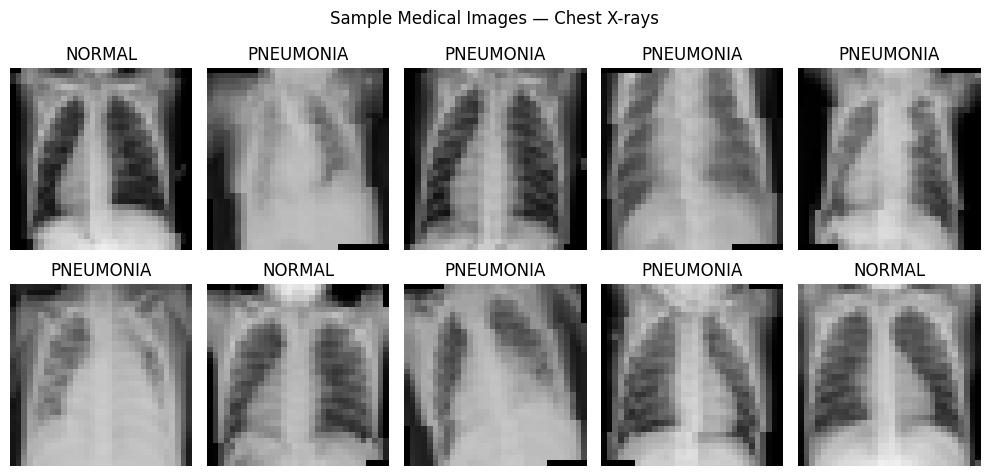

In [6]:
def unnormalize(img):
    return img / 2.0 + 0.5

images, labels = next(iter(train_loader))

plt.figure(figsize=(10, 5))
for i in range(min(10, len(images))):
    plt.subplot(2, 5, i + 1)
    img = unnormalize(images[i]).permute(1, 2, 0).numpy()
    plt.imshow(np.clip(img, 0, 1), cmap='gray')
    plt.title(class_names[labels[i]])
    plt.axis('off')

plt.suptitle('Sample Medical Images — Chest X-rays')
plt.tight_layout()
plt.show()


## 5. CNN Architecture


**Input (3 × 32 × 32)**  
↓  
**Conv2d (3 → 32, 3×3) + ReLU + MaxPool**  
↓  
**Conv2d (32 → 64, 3×3) + ReLU + MaxPool**  
↓  
**Conv2d (64 → 128, 3×3) + ReLU + MaxPool**  
↓  
**Flatten (128 × 4 × 4 = 2048)**  
↓  
**Fully Connected 2048 → 128 + ReLU**  
↓  
**Output 128 → 2**

This uses convolutional filters for spatial feature extraction and max pooling to reduce spatial dimensions, followed by fully connected classification.


In [7]:
class MedicalCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 128),
            nn.ReLU(),
            nn.Linear(128, 2)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        return self.fc_layers(x)

model = MedicalCNN().to(device)
print(model)
print('\nTrainable parameters:', sum(p.numel() for p in model.parameters() if p.requires_grad))


MedicalCNN(
  (conv_layers): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc_layers): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2048, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=2, bias=True)
  )
)

Trainable parameters: 355778


In [8]:
# Dimension walkthrough, following the style of the provided SICIP notebook.
dummy = torch.randn(1, 3, IMG_SIZE, IMG_SIZE).to(device)
x = dummy

print('0. Input:', list(x.shape))
for i, layer in enumerate(model.conv_layers):
    x = layer(x)
    print(f'{i+1:>2}. {layer.__class__.__name__:<12} -> {list(x.shape)}')

x = model.fc_layers[0](x)
print('Flatten        ->', list(x.shape))

for i, layer in enumerate(model.fc_layers[1:], start=1):
    x = layer(x)
    print(f'FC {i:<11} -> {list(x.shape)}')


0. Input: [1, 3, 32, 32]
 1. Conv2d       -> [1, 32, 32, 32]
 2. ReLU         -> [1, 32, 32, 32]
 3. MaxPool2d    -> [1, 32, 16, 16]
 4. Conv2d       -> [1, 64, 16, 16]
 5. ReLU         -> [1, 64, 16, 16]
 6. MaxPool2d    -> [1, 64, 8, 8]
 7. Conv2d       -> [1, 128, 8, 8]
 8. ReLU         -> [1, 128, 8, 8]
 9. MaxPool2d    -> [1, 128, 4, 4]
Flatten        -> [1, 2048]
FC 1           -> [1, 128]
FC 2           -> [1, 128]
FC 3           -> [1, 2]


## 6. Training

- **Loss:** Cross Entropy Loss
- **Optimizer:** Adam
- **Learning rate:** 0.001
- **Weight decay:** L2 regularization
- **Epochs:** 15
- **Checkpointing:** save the model with the lowest validation loss

The forward pass computes predictions, backpropagation computes gradients, and the optimizer updates the learnable CNN filters and fully connected weights.


In [9]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

NUM_EPOCHS = 15
best_val_loss = float('inf')

train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

for epoch in range(1, NUM_EPOCHS + 1):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        correct += (outputs.argmax(1) == targets).sum().item()
        total += targets.size(0)

    train_loss = running_loss / total
    train_acc = 100 * correct / total
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    model.eval()
    val_running = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)

            val_running += loss.item() * inputs.size(0)
            val_correct += (outputs.argmax(1) == targets).sum().item()
            val_total += targets.size(0)

    val_loss = val_running / val_total
    val_acc = 100 * val_correct / val_total
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    saved = ''
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'best_medical_cnn.pt')
        saved = ' [saved best checkpoint]'

    print(
        f'Epoch [{epoch:02d}/{NUM_EPOCHS}] | '
        f'Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | '
        f'Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%{saved}'
    )


Epoch [01/15] | Train Loss: 0.3838 | Train Acc: 82.72% | Val Loss: 0.2804 | Val Acc: 87.73% [saved best checkpoint]
Epoch [02/15] | Train Loss: 0.2028 | Train Acc: 92.16% | Val Loss: 0.1371 | Val Acc: 94.82% [saved best checkpoint]
Epoch [03/15] | Train Loss: 0.1490 | Train Acc: 94.46% | Val Loss: 0.1257 | Val Acc: 94.63% [saved best checkpoint]
Epoch [04/15] | Train Loss: 0.1200 | Train Acc: 95.49% | Val Loss: 0.1338 | Val Acc: 94.25%
Epoch [05/15] | Train Loss: 0.1050 | Train Acc: 95.97% | Val Loss: 0.0923 | Val Acc: 96.36% [saved best checkpoint]
Epoch [06/15] | Train Loss: 0.0957 | Train Acc: 96.31% | Val Loss: 0.0939 | Val Acc: 96.84%
Epoch [07/15] | Train Loss: 0.0889 | Train Acc: 96.41% | Val Loss: 0.0951 | Val Acc: 96.07%
Epoch [08/15] | Train Loss: 0.0940 | Train Acc: 96.29% | Val Loss: 0.1039 | Val Acc: 96.45%
Epoch [09/15] | Train Loss: 0.0815 | Train Acc: 97.00% | Val Loss: 0.0852 | Val Acc: 96.45% [saved best checkpoint]
Epoch [10/15] | Train Loss: 0.0727 | Train Acc: 97.2

## 7. Training and Validation Curves


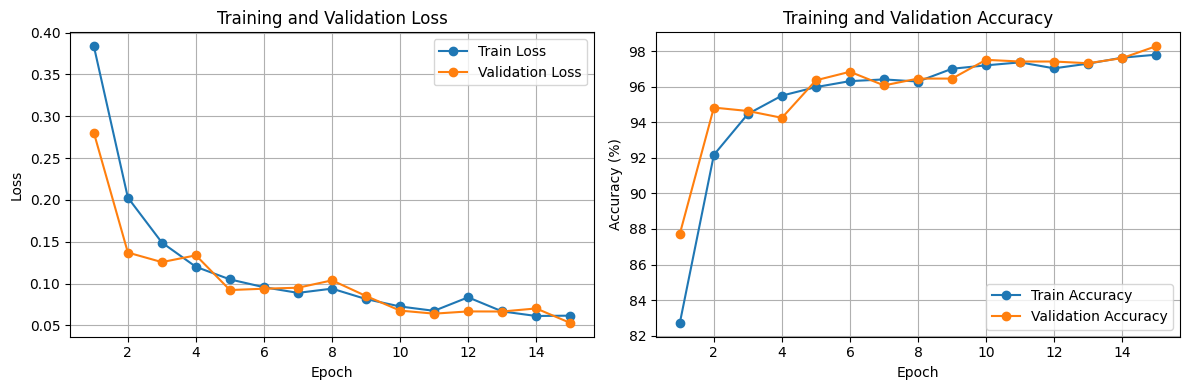

In [10]:
epochs = range(1, NUM_EPOCHS + 1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, marker='o', label='Train Loss')
plt.plot(epochs, val_losses, marker='o', label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs, train_accuracies, marker='o', label='Train Accuracy')
plt.plot(epochs, val_accuracies, marker='o', label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


## 8. Test Evaluation

We evaluate the best checkpoint on the unseen test set.

Metrics:
- Accuracy
- Precision
- Recall
- F1-score
- Confusion matrix


In [11]:
model.load_state_dict(torch.load('best_medical_cnn.pt', map_location=device))
model.eval()

all_targets, all_predictions = [], []

with torch.no_grad():
    for inputs, targets in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        predictions = outputs.argmax(1).cpu().numpy()

        all_predictions.extend(predictions.tolist())
        all_targets.extend(targets.numpy().tolist())

accuracy = accuracy_score(all_targets, all_predictions)
precision = precision_score(all_targets, all_predictions, average='binary', zero_division=0)
recall = recall_score(all_targets, all_predictions, average='binary', zero_division=0)
f1 = f1_score(all_targets, all_predictions, average='binary', zero_division=0)

print(f'Test Accuracy : {accuracy*100:.2f}%')
print(f'Precision     : {precision*100:.2f}%')
print(f'Recall        : {recall*100:.2f}%')
print(f'F1-score      : {f1*100:.2f}%')
print('\nClassification Report:\n')
print(classification_report(all_targets, all_predictions, target_names=class_names, zero_division=0))


Test Accuracy : 74.68%
Precision     : 71.17%
Recall        : 100.00%
F1-score      : 83.16%

Classification Report:

              precision    recall  f1-score   support

      NORMAL       1.00      0.32      0.49       234
   PNEUMONIA       0.71      1.00      0.83       390

    accuracy                           0.75       624
   macro avg       0.86      0.66      0.66       624
weighted avg       0.82      0.75      0.70       624



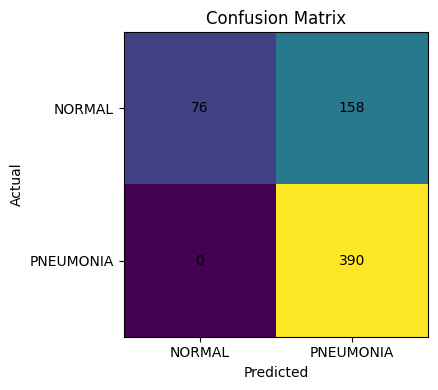

In [12]:
cm = confusion_matrix(all_targets, all_predictions)

plt.figure(figsize=(5, 4))
plt.imshow(cm)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(range(len(class_names)), class_names)
plt.yticks(range(len(class_names)), class_names)

for i in range(len(class_names)):
    for j in range(len(class_names)):
        plt.text(j, i, cm[i, j], ha='center', va='center')

plt.tight_layout()
plt.show()


## 9. Sample Test Predictions


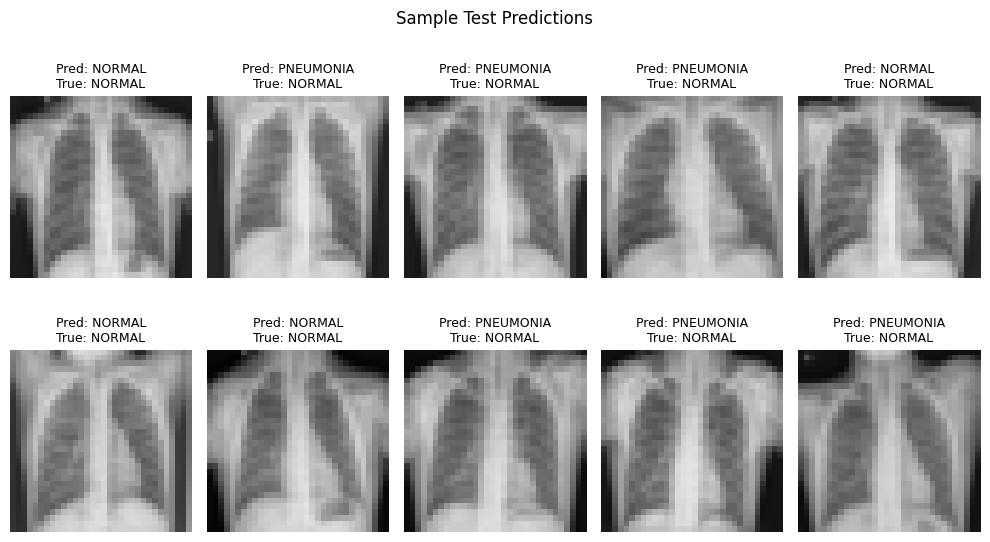

In [13]:
images, labels = next(iter(test_loader))
images_dev = images.to(device)

with torch.no_grad():
    outputs = model(images_dev)
    predictions = outputs.argmax(1).cpu()

plt.figure(figsize=(10, 6))
for i in range(min(10, len(images))):
    plt.subplot(2, 5, i + 1)
    img = unnormalize(images[i]).permute(1, 2, 0).numpy()
    plt.imshow(np.clip(img, 0, 1), cmap='gray')

    pred_name = class_names[predictions[i]]
    true_name = class_names[labels[i]]
    plt.title(f'Pred: {pred_name}\nTrue: {true_name}', fontsize=9)
    plt.axis('off')

plt.suptitle('Sample Test Predictions')
plt.tight_layout()
plt.show()


## 10. Methodology Summary

1. **Dataset:** Public chest X-ray pneumonia dataset.
2. **Preprocessing:** resize to 32×32, RGB conversion, normalization and light training augmentation.
3. **Split:** original training data → training + validation; original test data remains unseen for final testing.
4. **Feature extraction:** three CNN blocks using Conv2D, ReLU and MaxPool.
5. **Classification:** Flatten → Fully Connected → ReLU → two-class output.
6. **Optimization:** Cross Entropy Loss + Adam with L2 weight decay.
7. **Evaluation:** Accuracy, Precision, Recall, F1-score and Confusion Matrix.
8. **Visualization:** sample images, training/validation curves and sample predictions.

